## Correlation between global coffee production and CO2 concentration

In [4]:
# All notebooks start with the cell below to initialize database engine

from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, Engine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from IPython.display import HTML

load_dotenv("../.env")

# start psql engine to grab data from database
def get_engine() -> Engine:
    '''
    Depending on .env, it will load localhost or online DB
    priority is online DB
    '''
    DATABASE_URL = os.environ.get("DATABASE_URL")

    if not DATABASE_URL:
        DB_USER = os.environ.get("DB_USER")
        DB_PASSWORD = os.environ.get("DB_PASSWORD")
        DB_HOST = os.environ.get("DB_HOST", "localhost")
        DB_PORT = os.environ.get("DB_PORT", "5432")
        DB_NAME = os.environ.get("DB_NAME")

        if not all([DB_USER, DB_PASSWORD, DB_NAME]):
            raise RuntimeError(
                "Set either DATABASE_URL, or DB_USER/DB_PASSWORD/DB_NAME in .env"
            )

        DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

    else:
        DATABASE_URL = f"postgresql+psycopg2://{DATABASE_URL}"

    return create_engine(DATABASE_URL)

engine = get_engine()

In [9]:
# We need to transform year columns to row since global co2 dataset has years in row
# to do this in SQL is much more complicated.

query = """
SELECT *
FROM coffee_production
"""

coffee_prod_df = pd.read_sql(query, engine)

# create new df with year and total production to match co2 table
year_cols = [col for col in coffee_prod_df.columns if str(col) in [str(y) for y in range(1990, 2020)]]

# Sum down the rows (axis=0) and convert to a new DataFrame
coffee_total_by_year_df = coffee_prod_df[year_cols].sum().reset_index()

# Rename columns, year is str at this moment
coffee_total_by_year_df.columns = ['year', 'total_production']

# cast to integer
coffee_total_by_year_df['year'] = coffee_total_by_year_df['year'].astype(int)
coffee_total_by_year_df.head()


,year,total_production
0,1990,5593800000
1,1991,6076140000
2,1992,5911260000
3,1993,5505540000
4,1994,5598840000


In [17]:
# select global CO2 dataset (1990-2019) and merge it into coffee production

query = """
SELECT *
FROM global_co2
WHERE year BETWEEN 1990 and 2019
"""

co2_df = pd.read_sql(query, engine)

# cast year as int so that it works during merge with coffee_production
co2_df['year'] = co2_df['year'].astype(int)

coffee_co2_df = coffee_total_by_year_df.merge(co2_df, on='year', how='left')
coffee_co2_df = coffee_co2_df[['year','total_production','co2_concentration']]
coffee_co2_df.head()

,year,total_production,co2_concentration
0,1990,5593800000,354.05835
1,1991,6076140000,355.39667
2,1992,5911260000,356.09332
3,1993,5505540000,356.83917
4,1994,5598840000,358.32834


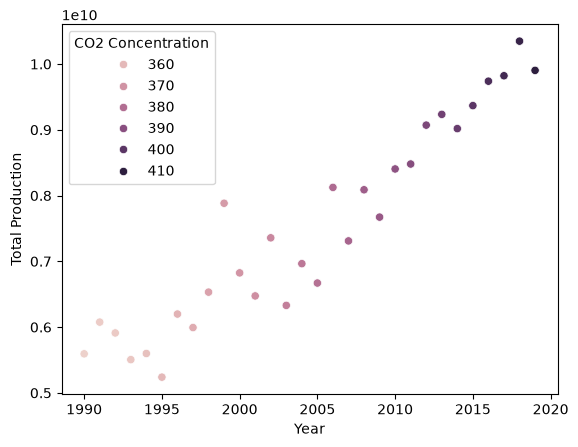

In [19]:
ax = sns.scatterplot(data=coffee_co2_df,x='year',y='total_production',hue='co2_concentration')
plt.ylabel("Total Production")
plt.xlabel("Year")
ax.legend(title="CO2 Concentration")
plt.show()

In [ ]:
year_cols = [str(y) for y in range(1990, 2020)]
export_df = coffee_prod_df[["country"] + year_cols]

long_df = export_df.melt(id_vars="country", var_name="year", value_name="volume")
long_df["volume"] = long_df["volume"] / 1_000_000
long_df.to_csv("coffee_production_long.csv", index=False)